IMPORTS

In [6]:
import os
import sys
from pathlib import Path

ROOT = Path(os.path.abspath('')).resolve().parents[2]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import nvitk.core as core
# core.setup(globals())

import nvitk as nv

In [ ]:
# im = nv.imread('/home/imarcoss/NetVolumes/Tierra/GENERAL_SC/PESA-Fat/Visit-5-DIXON_PET-CT/IMAGES/202602_Week1/PESA11471769/PET_PESA11471769', force_type='dicom')
# im

Image(shape=(288, 288, 490), dtype=float64, backend=cupy, axes='XYZ', orientation='LPS', name='PET_PESA11471769', modality='PT', submodality='[DetailWB_CTAC] Vascular', rescale_type='DV')

In [ ]:
# im.dicom_tags.get('SeriesNumber')

1381

In [10]:
tof = nv.imread('/home/imarcoss/DATA/LabVF/PESA-Brain/WVI-BB/RESULTS/eicab_test/PESA15689521/TOF_resampled.nii.gz')
eicab = nv.imread('/home/imarcoss/DATA/LabVF/PESA-Brain/WVI-BB/RESULTS/eicab_test/PESA15689521/TOF_eICAB_CW.nii.gz')

## ICA pipeline (bbox Otsu → cut donut shortcut → centerline along full vessel)

**Problem:** When the siphon walls touch, segmentation closes a false bridge. The centerline
then **shortcuts** through the chord (straight "rect tube") instead of following the **full ICA
path around the loop**.

**Repair:** Cut thin neck voxels that **shorten** the geodesic between ICA endpoints (remove the
false bridge), not "open" the whole vessel.

**Centerline:** Prefer the **skeleton path** between endpoints when it is longer than the MCP
chord (loop-following); MCP is fallback.



In [11]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu

from nvitk.core.array import to_numpy
from nvitk.morphology.centerline import compute_centerlines
from nvitk.morphology.components import remove_small_components_by_fraction
from nvitk.pipes.bbtpy.labels import (
    BB_LICA,
    BB_RICA,
    BB_ARTERIAL_LABEL_IDS,
    bb_vessel_name,
    relabel_eicab_to_bb,
)
from nvitk.pipes.bbtpy.util.centerlines_from_eicab import rasterize_centerlines_mask

ICA_IDS = (BB_LICA, BB_RICA)
CROP_PAD = 7
CL_BARRIER_RADIUS = 5
MIN_COMPONENT_FRAC = 0.005


def bbox_with_padding(roi: np.ndarray, shape, pad: int):
    xs, ys, zs = np.nonzero(roi)
    if xs.size == 0:
        return None
    nx, ny, nz = shape
    p = max(0, int(pad))
    return (
        max(0, int(xs.min()) - p),
        min(nx - 1, int(xs.max()) + p),
        max(0, int(ys.min()) - p),
        ny - 1,
        # min(ny - 1, int(ys.max()) + p),
        max(0, int(zs.min()) - p),
        min(nz - 1, int(zs.max()) + p),
    )


def local_otsu_mask(wvi_crop: np.ndarray, *, intensity_max: float) -> tuple[np.ndarray, float]:
    """TOF lumen is hyperintense: apply Otsu directly to intensities inside the crop."""
    data = wvi_crop.astype(np.float64)
    pos = data[data > 0]
    if pos.size < 2:
        return np.zeros(wvi_crop.shape, dtype=bool), np.nan
    t = float(threshold_otsu(pos))
    mask = data > t
    if MIN_COMPONENT_FRAC > 0:
        mask = remove_small_components_by_fraction(
            mask, min_fraction=MIN_COMPONENT_FRAC, connectivity=1
        )
    return mask, t


def dilated_other_centerlines(clm: np.ndarray, label_id: int, bbox, radius: int) -> np.ndarray:
    from scipy import ndimage

    i0, i1, j0, j1, k0, k1 = bbox
    other = (clm != 0) & (clm != int(label_id))
    if radius > 0 and np.any(other):
        other = ndimage.binary_dilation(other, iterations=radius)
    return other[i0 : i1 + 1, j0 : j1 + 1, k0 : k1 + 1]


def refine_ica_mask_otsu(
    wvi: np.ndarray,
    cl_mask: np.ndarray,
    lid: int,
    shape: tuple[int, int, int],
    seg_accum: np.ndarray,
    *,
    intensity_max: float,
    crop_pad: int = CROP_PAD,
    cl_barrier_radius: int = CL_BARRIER_RADIUS,
) -> tuple[np.ndarray, dict]:
    """BBox + local Otsu ICA mask (full volume) with CL barriers and no label overlap."""
    name = bb_vessel_name(lid)
    roi = cl_mask == lid
    bbox = bbox_with_padding(roi, shape, crop_pad)
    if bbox is None:
        return np.zeros(shape, dtype=bool), {
            "label": name,
            "n_voxels": 0,
            "warning": "no centerline seed",
        }

    i0, i1, j0, j1, k0, k1 = bbox
    crop = wvi[i0 : i1 + 1, j0 : j1 + 1, k0 : k1 + 1]
    mask, t = local_otsu_mask(crop, intensity_max=intensity_max)
    forbidden = dilated_other_centerlines(cl_mask, lid, bbox, cl_barrier_radius)
    slab = seg_accum[i0 : i1 + 1, j0 : j1 + 1, k0 : k1 + 1]
    write = mask & (slab == 0) & ~forbidden

    full = np.zeros(shape, dtype=bool)
    full[i0 : i1 + 1, j0 : j1 + 1, k0 : k1 + 1] = write
    from nvitk.core.logger import Logger

    Logger().step(
        f"[{name}] Otsu crop: thresh={t:.3g} voxels={int(np.count_nonzero(write))} "
        f"bbox=({i0},{i1},{j0},{j1},{k0},{k1})"
    )
    return full, {
        "label": name,
        "bbox": bbox,
        "otsu_thresh": t,
        "n_voxels": int(np.count_nonzero(write)),
    }



In [12]:
"""ICA topology: cut donut shortcuts, centerline along full vessel path."""

from __future__ import annotations

import logging
from collections import deque
from dataclasses import dataclass, field

import numpy as np
from scipy import ndimage as ndi
from skimage.graph import route_through_array
from skimage.measure import euler_number
from skimage.morphology import reconstruction as morph_reconstruction

from nvitk.core.logger import Logger
from nvitk.morphology import open as morph_open
from nvitk.morphology.centerline import compute_centerlines, skeletonize_binary
from nvitk.morphology.components import label_connected

log = Logger()
logging.getLogger("nvitk").setLevel(logging.DEBUG)


@dataclass(frozen=True)
class GenusReport:
    label_name: str
    n_voxels: int
    n_components: int
    euler_chi: float
    beta0: int
    beta1: int
    skeleton_cycles: int = 0

    @property
    def genus_suspect(self) -> bool:
        return self.beta1 > 0 or self.skeleton_cycles > 0


@dataclass
class RepairLog:
    label_name: str
    action: str = "none"
    open_radius_used: int = 0
    neck_cuts: int = 0
    n_voxels_before: int = 0
    n_voxels_after: int = 0
    geodesic_before: int = 0
    geodesic_after: int = 0
    before: GenusReport | None = None
    after: GenusReport | None = None
    notes: list[str] = field(default_factory=list)


def _voxel_size_mm_from_metadata(metadata: dict | None) -> tuple[float, float, float] | None:
    if not metadata:
        return None
    zooms = metadata.get("zooms") or metadata.get("pixdim")
    if zooms is None or len(zooms) < 3:
        return None
    return tuple(float(z) for z in zooms[:3])


def _neighbors26(p: tuple[int, int, int]) -> list[tuple[int, int, int]]:
    x, y, z = p
    out: list[tuple[int, int, int]] = []
    for dx in (-1, 0, 1):
        for dy in (-1, 0, 1):
            for dz in (-1, 0, 1):
                if dx == dy == dz == 0:
                    continue
                out.append((x + dx, y + dy, z + dz))
    return out


def skeleton_cycle_count(mask: np.ndarray) -> int:
    sk = np.asarray(skeletonize_binary(mask), dtype=bool)
    coords = np.argwhere(sk)
    if coords.shape[0] < 3:
        return 0
    nodes = [tuple(int(v) for v in row) for row in coords]
    node_set = set(nodes)
    parent: dict[tuple[int, int, int], tuple[int, int, int] | None] = {}
    n_comp = 0
    edges = 0
    for n in nodes:
        if n in parent:
            continue
        n_comp += 1
        stack = [n]
        parent[n] = None
        while stack:
            u = stack.pop()
            for v in _neighbors26(u):
                if v not in node_set:
                    continue
                edges += 1
                if v not in parent:
                    parent[v] = u
                    stack.append(v)
    edges //= 2
    return max(0, int(edges) - len(nodes) + n_comp)


def compute_genus_report(
    mask: np.ndarray,
    *,
    label_name: str = "vessel",
    connectivity: int = 1,
) -> GenusReport:
    m = np.asarray(mask, dtype=bool)
    n_vox = int(np.count_nonzero(m))
    if n_vox == 0:
        return GenusReport(label_name, 0, 0, 0.0, 0, 0, 0)

    labeled, n_cc = label_connected(m, connectivity=connectivity)
    labeled_np = np.asarray(labeled)
    chi_sum = 0.0
    for comp_id in range(1, int(n_cc) + 1):
        comp = labeled_np == comp_id
        chi_sum += float(euler_number(comp, connectivity=connectivity))

    beta0 = int(n_cc)
    beta1 = max(0, int(beta0 - round(chi_sum)))
    cycles = skeleton_cycle_count(m)
    return GenusReport(
        label_name=label_name,
        n_voxels=n_vox,
        n_components=beta0,
        euler_chi=float(chi_sum),
        beta0=beta0,
        beta1=beta1,
        skeleton_cycles=cycles,
    )


def _topology_score(rep: GenusReport) -> tuple[int, int, int]:
    # lower is better; tie-break: more voxels kept
    return (rep.beta1, rep.skeleton_cycles, -rep.n_voxels)


def _log_genus(rep: GenusReport, *, stage: str) -> None:
    log.step(
        f"[{rep.label_name}] {stage}: voxels={rep.n_voxels} "
        f"β₀={rep.beta0} β₁={rep.beta1} χ={rep.euler_chi:.2f} "
        f"skel_cycles={rep.skeleton_cycles} suspect={rep.genus_suspect}"
    )


def seed_centerline_endpoints(cl_mask: np.ndarray, lid: int):
    """Endpoints from the eICAB seed centerline of label *lid*:
    init = voxel with the lowest Z; fin = voxel with the highest Z.
    Returns (init, fin) as (i, j, k) tuples, or None if no seed voxels.
    """
    coords = np.argwhere(cl_mask == int(lid))
    if coords.shape[0] == 0:
        return None
    init_idx = int(np.argmin(coords[:, 2]))
    fin_idx = int(np.argmax(coords[:, 2]))
    init = tuple(int(v) for v in coords[init_idx])
    fin = tuple(int(v) for v in coords[fin_idx])
    return init, fin


def mask_pca_endpoints(mask: np.ndarray) -> tuple[tuple[int, int, int], tuple[int, int, int]]:
    coords = np.argwhere(mask)
    if coords.shape[0] < 2:
        v = tuple(int(x) for x in coords[0]) if coords.shape[0] else (0, 0, 0)
        return v, v
    ctr = coords.astype(np.float64).mean(axis=0)
    cov = np.cov(coords.astype(np.float64).T)
    w, vecs = np.linalg.eigh(cov)
    axis = vecs[:, int(np.argmax(w))]
    proj = (coords.astype(np.float64) - ctr) @ axis
    i0, i1 = int(np.argmin(proj)), int(np.argmax(proj))
    return tuple(int(v) for v in coords[i0]), tuple(int(v) for v in coords[i1])


def _snap_to_mask(mask: np.ndarray, p: tuple[int, int, int]) -> tuple[int, int, int]:
    m = np.asarray(mask, dtype=bool)
    if m[p]:
        return p
    _, indices = ndi.distance_transform_edt(~m, return_indices=True)
    return tuple(int(indices[i][p[0], p[1], p[2]]) for i in range(3))


def geodesic_voxel_length(
    mask: np.ndarray,
    start: tuple[int, int, int],
    end: tuple[int, int, int],
) -> int:
    """26-connected BFS path length inside mask (0 if disconnected)."""
    m = np.asarray(mask, dtype=bool)
    if not np.any(m):
        return 0
    s = _snap_to_mask(m, start)
    e = _snap_to_mask(m, end)
    if s == e:
        return 1
    q: deque[tuple[tuple[int, int, int], int]] = deque([(s, 1)])
    seen = {s}
    nx, ny, nz = m.shape
    while q:
        u, d = q.popleft()
        for v in _neighbors26(u):
            if not (0 <= v[0] < nx and 0 <= v[1] < ny and 0 <= v[2] < nz):
                continue
            if not m[v] or v in seen:
                continue
            if v == e:
                return d + 1
            seen.add(v)
            q.append((v, d + 1))
    return 0


def consolidate_ica_mask(
    mask: np.ndarray,
    start: tuple[int, int, int],
    end: tuple[int, int, int],
    *,
    label_name: str,
) -> np.ndarray:
    """Keep component(s) through endpoints; drop stray islands."""
    m = np.asarray(mask, dtype=bool)
    labeled, n_cc = label_connected(m, connectivity=1)
    labeled_np = np.asarray(labeled)
    if n_cc <= 1:
        return m
    nx, ny, nz = m.shape

    def _lab(p: tuple[int, int, int]) -> int:
        if not (0 <= p[0] < nx and 0 <= p[1] < ny and 0 <= p[2] < nz):
            return 0
        return int(labeled_np[p])

    s_lab, e_lab = _lab(start), _lab(end)
    if s_lab > 0 and s_lab == e_lab:
        out = labeled_np == s_lab
        log.step(f"[{label_name}] consolidate: kept component {s_lab} (both endpoints)")
        return out

    keep = np.zeros_like(m, dtype=bool)
    if s_lab > 0:
        keep |= labeled_np == s_lab
    if e_lab > 0 and e_lab != s_lab:
        keep |= labeled_np == e_lab
    if np.any(keep):
        log.step(f"[{label_name}] consolidate: kept endpoint component(s)")
        return keep

    counts = np.bincount(labeled_np.ravel())
    largest = int(1 + np.argmax(counts[1:]))
    log.step(f"[{label_name}] consolidate: kept largest component {largest}")
    return labeled_np == largest


def keep_component_through_endpoints(
    mask: np.ndarray,
    start: tuple[int, int, int],
    end: tuple[int, int, int],
    *,
    connectivity: int = 1,
) -> np.ndarray:
    m = np.asarray(mask, dtype=bool)
    labeled, n_cc = label_connected(m, connectivity=connectivity)
    labeled_np = np.asarray(labeled)
    if n_cc <= 1:
        return m

    nx, ny, nz = m.shape

    def _in_bounds(p: tuple[int, int, int]) -> bool:
        return 0 <= p[0] < nx and 0 <= p[1] < ny and 0 <= p[2] < nz

    s_lab = int(labeled_np[start]) if _in_bounds(start) else 0
    e_lab = int(labeled_np[end]) if _in_bounds(end) else 0
    if s_lab > 0 and s_lab == e_lab:
        return labeled_np == s_lab

    counts = np.bincount(labeled_np.ravel())
    largest = int(1 + np.argmax(counts[1:]))
    return labeled_np == largest


def _opening_by_reconstruction(mask: np.ndarray, *, open_radius: int) -> np.ndarray:
    original = np.asarray(mask, dtype=bool)
    opened = np.asarray(
        morph_open(original.astype(np.uint8), footprint=int(open_radius), connectivity=1),
        dtype=bool,
    )
    restored = morph_reconstruction(
        opened.astype(np.uint8),
        original.astype(np.uint8),
        method="dilation",
    )
    return np.asarray(restored, dtype=bool)


def _dt_local_minima_indices(mask: np.ndarray, dt: np.ndarray) -> list[tuple[int, int, int]]:
    m = np.asarray(mask, dtype=bool)
    mins: list[tuple[int, int, int]] = []
    for x, y, z in np.argwhere(m):
        val = float(dt[x, y, z])
        if val <= 0:
            continue
        if all(
            (not m[nx, ny, nz]) or float(dt[nx, ny, nz]) >= val - 1e-6
            for nx, ny, nz in _neighbors26((int(x), int(y), int(z)))
        ):
            mins.append((int(x), int(y), int(z)))
    return mins


def _cut_shortcut_bridges(
    mask: np.ndarray,
    *,
    label_name: str,
    start: tuple[int, int, int],
    end: tuple[int, int, int],
    voxel_size_mm: tuple[float, float, float] | None,
    max_cuts: int = 120,
    neck_frac: float = 0.5,
    min_geo_gain: int = 2,
) -> tuple[np.ndarray, int]:
    """Remove thin neck voxels that shorten the geodesic (donut chord bridges)."""
    m = np.asarray(mask, dtype=bool).copy()
    sampling = voxel_size_mm if voxel_size_mm is not None else (1.0, 1.0, 1.0)
    cuts = 0
    geo = geodesic_voxel_length(m, start, end)
    log.step(f"[{label_name}] shortcut-cut: initial geodesic={geo}")

    for _ in range(int(max_cuts)):
        rep = compute_genus_report(m, label_name=label_name)
        if not rep.genus_suspect and geo > 0:
            break
        dt = ndi.distance_transform_edt(m, sampling=sampling)
        if not np.any(m):
            break
        thresh = float(neck_frac) * float(dt[m].max())
        candidates = [p for p in _dt_local_minima_indices(m, dt) if float(dt[p]) <= thresh]
        if not candidates:
            candidates = _dt_local_minima_indices(m, dt)
        if not candidates:
            break
        candidates.sort(key=lambda p: float(dt[p]))

        accepted = False
        for cut_vox in candidates:
            trial = m.copy()
            trial[cut_vox] = False
            trial = keep_component_through_endpoints(trial, start, end)
            geo2 = geodesic_voxel_length(trial, start, end)
            if geo2 == 0:
                continue
            # accept if topology improves OR geodesic lengthens (chord removed)
            rep2 = compute_genus_report(trial, label_name=label_name)
            gain = geo2 - geo
            topo_better = _topology_score(rep2) < _topology_score(rep)
            if topo_better or gain >= int(min_geo_gain):
                m = trial
                cuts += 1
                geo = geo2
                accepted = True
                log.step(
                    f"[{label_name}] cut #{cuts} {cut_vox} DT={float(dt[cut_vox]):.2f} "
                    f"geo {geo - gain}→{geo} β₁={rep.beta1}→{rep2.beta1} "
                    f"cycles={rep.skeleton_cycles}→{rep2.skeleton_cycles}"
                )
                break
        if not accepted:
            log.step(f"[{label_name}] shortcut-cut: no improving cut at iter {_ + 1}")
            break

    return m, cuts


def break_genus_handles(
    mask: np.ndarray,
    *,
    label_name: str,
    max_open_radius: int = 5,
    mild_max_radius: int = 2,
    neck_dt_frac: float = 0.5,
    voxel_size_mm: tuple[float, float, float] | None = None,
    endpoints: tuple[tuple[int, int, int], tuple[int, int, int]] | None = None,
    force_repair: bool = True,
    min_voxel_frac: float = 0.25,
) -> tuple[np.ndarray, RepairLog]:
    """Cut false bridges that shortcut the siphon; keep the long lumen path."""
    original = np.asarray(mask, dtype=bool)
    rlog = RepairLog(
        label_name=label_name,
        n_voxels_before=int(np.count_nonzero(original)),
    )
    if endpoints is None:
        endpoints = mask_pca_endpoints(original)
    start, end = endpoints

    m = consolidate_ica_mask(original, start, end, label_name=label_name)
    rlog.before = compute_genus_report(m, label_name=label_name)
    rlog.geodesic_before = geodesic_voxel_length(m, start, end)
    _log_genus(rlog.before, stage="before repair")
    log.step(f"[{label_name}] geodesic before repair: {rlog.geodesic_before}")

    if not rlog.before.genus_suspect and not force_repair:
        rlog.action = "skip_ok"
        rlog.after = rlog.before
        rlog.n_voxels_after = int(np.count_nonzero(m))
        rlog.geodesic_after = rlog.geodesic_before
        return m, rlog

    rlog.action = "repair_mild" if not rlog.before.genus_suspect else "repair"
    min_voxels = max(64, int(min_voxel_frac * rlog.n_voxels_before))
    best = m.copy()
    best_rep = rlog.before
    best_score = _topology_score(best_rep)

    # Phase 1: targeted neck cuts that lengthen geodesic / lower genus
    m, neck_cuts = _cut_shortcut_bridges(
        m,
        label_name=label_name,
        start=start,
        end=end,
        voxel_size_mm=voxel_size_mm,
        neck_frac=neck_dt_frac,
    )
    rlog.neck_cuts = neck_cuts
    rep = compute_genus_report(m, label_name=label_name)
    if _topology_score(rep) < best_score and rep.n_voxels >= min_voxels:
        best, best_rep, best_score = m.copy(), rep, _topology_score(rep)

    # Phase 2: mild opening+recon — never take empty mask; track best
    if rep.genus_suspect or force_repair:
        open_cap = int(max_open_radius if rlog.before.genus_suspect else mild_max_radius)
        log.step(f"[{label_name}] opening+recon phase open_r=1..{open_cap}")
        base = m.copy()
        for radius in range(1, open_cap + 1):
            candidate = _opening_by_reconstruction(base, open_radius=radius)
            n_cand = int(np.count_nonzero(candidate))
            if n_cand == 0:
                log.warning(f"[{label_name}] open r={radius} emptied mask — stop opening")
                break
            if n_cand < min_voxels:
                log.warning(
                    f"[{label_name}] open r={radius} too small ({n_cand}<{min_voxels}) — stop"
                )
                break
            candidate = keep_component_through_endpoints(candidate, start, end)
            rep_c = compute_genus_report(candidate, label_name=label_name)
            log.step(
                f"[{label_name}] open r={radius}: voxels={rep_c.n_voxels} "
                f"β₁={rep_c.beta1} cycles={rep_c.skeleton_cycles}"
            )
            score = _topology_score(rep_c)
            if score < best_score:
                best = candidate
                best_rep = rep_c
                best_score = score
                rlog.open_radius_used = radius
            if not rep_c.genus_suspect:
                rlog.notes.append(f"simple after open r={radius}")
                break

    m = keep_component_through_endpoints(best, start, end)
    if int(np.count_nonzero(m)) < min_voxels:
        log.warning(f"[{label_name}] repair too small — partial revert to consolidated")
        m = keep_component_through_endpoints(
            consolidate_ica_mask(original, start, end, label_name=label_name), start, end
        )
        rlog.notes.append("revert_partial")

    # Phase 3: extra shortcut cuts on best mask if still suspect
    rep = compute_genus_report(m, label_name=label_name)
    if rep.genus_suspect:
        m2, extra = _cut_shortcut_bridges(
            m,
            label_name=label_name,
            start=start,
            end=end,
            voxel_size_mm=voxel_size_mm,
            neck_frac=neck_dt_frac,
        )
        rlog.neck_cuts += extra
        if int(np.count_nonzero(m2)) >= min_voxels:
            m = m2

    m = keep_component_through_endpoints(m, start, end)
    rlog.after = compute_genus_report(m, label_name=label_name)
    rlog.n_voxels_after = int(np.count_nonzero(m))
    rlog.geodesic_after = geodesic_voxel_length(m, start, end)
    _log_genus(rlog.after, stage="after repair")
    log.step(
        f"[{label_name}] geodesic after repair: {rlog.geodesic_before}→{rlog.geodesic_after}"
    )
    changed = rlog.n_voxels_after != rlog.n_voxels_before
    log.step(
        f"[{label_name}] repair done: changed={changed} Δvoxels="
        f"{rlog.n_voxels_after - rlog.n_voxels_before}"
    )
    return m, rlog


def _skeleton_path_between_endpoints(
    mask: np.ndarray,
    start: tuple[int, int, int],
    end: tuple[int, int, int],
) -> np.ndarray | None:
    sk = np.asarray(skeletonize_binary(mask), dtype=bool)
    if not np.any(sk):
        return None
    coords = np.argwhere(sk)
    nodes = [tuple(int(v) for v in row) for row in coords]
    node_set = set(nodes)

    def _nearest_sk(p: tuple[int, int, int]) -> tuple[int, int, int]:
        best = nodes[0]
        bd = np.inf
        for n in nodes:
            d = (n[0] - p[0]) ** 2 + (n[1] - p[1]) ** 2 + (n[2] - p[2]) ** 2
            if d < bd:
                bd, best = d, n
        return best

    s, e = _nearest_sk(start), _nearest_sk(end)
    parent: dict[tuple[int, int, int], tuple[int, int, int] | None] = {s: None}
    q: deque[tuple[int, int, int]] = deque([s])
    while q:
        u = q.popleft()
        if u == e:
            path: list[tuple[int, int, int]] = []
            cur: tuple[int, int, int] | None = e
            while cur is not None:
                path.append(cur)
                cur = parent.get(cur)
            path.reverse()
            return np.asarray(path, dtype=np.float32)
        for v in _neighbors26(u):
            if v not in node_set or v in parent:
                continue
            parent[v] = u
            q.append(v)
    return None


def centerline_path_through_mask(
    mask: np.ndarray,
    *,
    start: tuple[int, int, int],
    end: tuple[int, int, int],
    voxel_size_mm: tuple[float, float, float] | None = None,
    label_name: str = "vessel",
) -> np.ndarray:
    """Centerline along lumen: prefer skeleton geodesic; MCP if skeleton fails."""
    m = np.asarray(mask, dtype=bool)
    if not np.any(m):
        return np.empty((0, 3), dtype=np.float32)

    sk_path = _skeleton_path_between_endpoints(m, start, end)
    geo = geodesic_voxel_length(m, start, end)

    sampling = voxel_size_mm if voxel_size_mm is not None else (1.0, 1.0, 1.0)
    dt = ndi.distance_transform_edt(m, sampling=sampling)
    cost = np.full(m.shape, np.inf, dtype=np.float64)
    cost[m] = 1.0 / (dt[m] + 1e-3)

    s = _snap_to_mask(m, start)
    e = _snap_to_mask(m, end)
    mcp, mcp_cost = route_through_array(
        cost,
        np.asarray(s, dtype=np.int32),
        np.asarray(e, dtype=np.int32),
        fully_connected=True,
    )
    mcp = np.asarray(mcp, dtype=np.float32)

    if sk_path is not None and sk_path.shape[0] >= 3:
        len_sk = int(sk_path.shape[0])
        len_mcp = int(mcp.shape[0])
        # After bridge cut, skeleton path is often longer and follows the loop.
        if len_sk >= len_mcp or (geo > 0 and len_mcp < int(0.85 * geo)):
            log.step(
                f"[{label_name}] centerline: skeleton path len={len_sk} "
                f"(MCP len={len_mcp}, geo={geo})"
            )
            return sk_path
        log.step(
            f"[{label_name}] centerline: MCP len={len_mcp} "
            f"(skeleton len={len_sk}, geo={geo})"
        )
        return mcp

    log.step(f"[{label_name}] centerline: MCP only len={mcp.shape[0]} cost={float(mcp_cost):.4f}")
    return mcp


def repair_ica_mask_and_centerline(
    mask: np.ndarray,
    *,
    label_name: str,
    endpoints: tuple[tuple[int, int, int], tuple[int, int, int]] | None = None,
    max_open_radius: int = 5,
    mild_max_radius: int = 2,
    neck_dt_frac: float = 0.5,
    voxel_size_mm: tuple[float, float, float] | None = None,
    force_repair: bool = True,
) -> tuple[np.ndarray, GenusReport, GenusReport, np.ndarray, RepairLog]:
    if endpoints is None:
        endpoints = mask_pca_endpoints(mask)
        log.step(f"[{label_name}] PCA endpoints {endpoints[0]} → {endpoints[1]}")
    else:
        log.step(f"[{label_name}] seed-CL endpoints init={endpoints[0]} fin={endpoints[1]}")

    repaired, rlog = break_genus_handles(
        mask,
        label_name=label_name,
        max_open_radius=max_open_radius,
        mild_max_radius=mild_max_radius,
        neck_dt_frac=neck_dt_frac,
        voxel_size_mm=voxel_size_mm,
        endpoints=endpoints,
        force_repair=force_repair,
    )
    path = centerline_path_through_mask(
        repaired,
        start=endpoints[0],
        end=endpoints[1],
        voxel_size_mm=voxel_size_mm,
        label_name=label_name,
    )
    return repaired, rlog.before, rlog.after, path, rlog



17:29:13 | INFO     |   ▸ === ICA pipeline start ===
17:29:14 | INFO     |   ▸ volume shape=(347, 401, 192) voxel_size_mm=None
17:29:14 | INFO     |   ▸ BB labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 12]
17:29:16 | INFO     |   ▸ seed centerline LICA: 59 voxels
17:29:16 | INFO     |   ▸ seed centerline RICA: 51 voxels
17:29:16 | INFO     |   ▸ --- LICA (label 1) ---
17:29:16 | INFO     |   ▸ [LICA] Otsu crop: thresh=5.83e+04 voxels=7245 bbox=(136,160,221,400,18,74)
17:29:16 | INFO     |   ▸ [LICA] Otsu: thresh=58322.813907216 voxels=7245 bbox=(136, 160, 221, 400, 18, 74)
17:29:16 | INFO     |   ▸ [LICA] PCA endpoints (136, 221, 18) → (154, 260, 55)
17:29:16 | INFO     |   ▸ [LICA] consolidate: kept component 1 (both endpoints)
17:29:17 | INFO     |   ▸ [LICA] before repair: voxels=7241 β₀=1 β₁=2 χ=-1.00 skel_cycles=7 suspect=True
17:29:17 | INFO     |   ▸ [LICA] geodesic before repair: 59
17:29:17 | INFO     |   ▸ [LICA] shortcut-cut: initial geodesic=59
17:29:39 | INFO     |   ▸ [LICA] cut #1

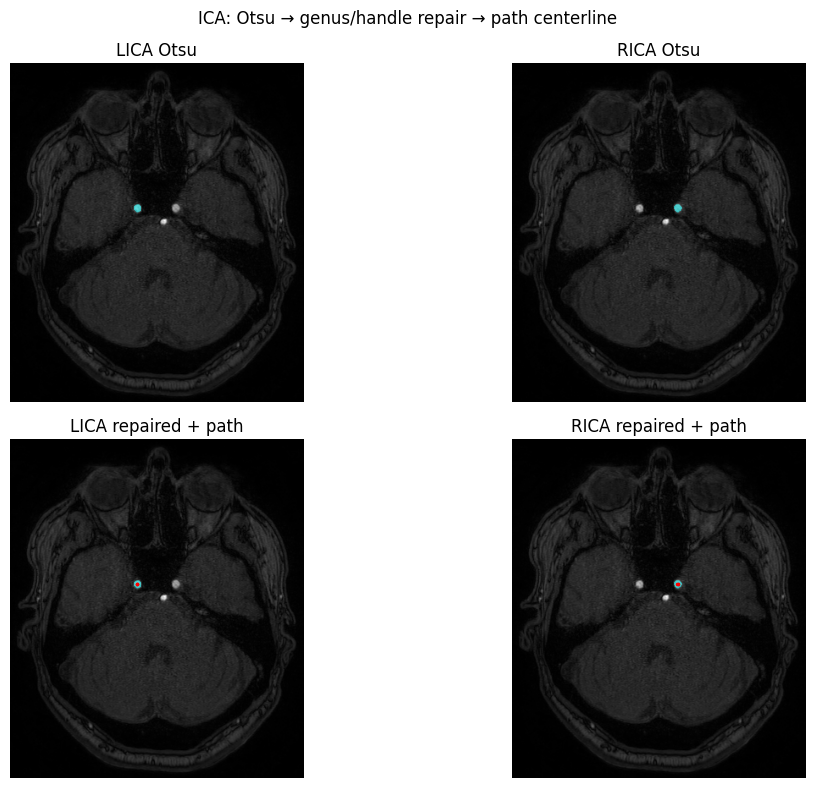

In [ ]:
# --- Unified ICA pipeline: Otsu → genus/handle repair → path centerline ---
MAX_OPEN_RADIUS = 5
MILD_OPEN_RADIUS = 2
NECK_DT_FRAC = 0.5
FORCE_ICA_TOPO_REPAIR = True  # always try opening+recon on ICA Otsu masks

log.step("=== ICA pipeline start ===")

with core.using("numpy"):
    wvi = to_numpy(tof.data).astype(np.float32)
    eicab_np = to_numpy(eicab.data).astype(np.int32)
    shape = tuple(int(s) for s in wvi.shape[:3])
    intensity_max = float(wvi.max()) or 1.0
    voxel_size = _voxel_size_mm_from_metadata(dict(tof.metadata or {}))
    log.step(f"volume shape={shape} voxel_size_mm={voxel_size}")

    bb = relabel_eicab_to_bb(eicab_np)
    log.step(f"BB labels: {sorted(int(v) for v in np.unique(bb) if v > 0)}")

    cl_seed = compute_centerlines(
        bb, labels=sorted(BB_ARTERIAL_LABEL_IDS), min_points=3
    )
    cl_mask = rasterize_centerlines_mask(shape, cl_seed)
    for lid in ICA_IDS:
        n = int(np.count_nonzero(cl_mask == lid))
        log.step(f"seed centerline {bb_vessel_name(lid)}: {n} voxels")

    seg_ica_otsu = np.zeros(shape, dtype=np.int32)
    seg_ica_topo = np.zeros(shape, dtype=np.int32)
    ica_centerlines_path: dict[int, np.ndarray] = {}
    pipeline_log: list[dict] = []

    for lid in ICA_IDS:
        name = bb_vessel_name(lid)
        log.step(f"--- {name} (label {lid}) ---")

        otsu_mask, otsu_info = refine_ica_mask_otsu(
            wvi,
            cl_mask,
            lid,
            shape,
            seg_ica_otsu,
            intensity_max=intensity_max,
        )
        if "warning" in otsu_info:
            log.warning(f"[{name}] Otsu skipped: {otsu_info['warning']}")
            pipeline_log.append({**otsu_info, "label": name})
            continue

        seg_ica_otsu[otsu_mask] = int(lid)
        log.step(
            f"[{name}] Otsu: thresh={otsu_info.get('otsu_thresh')} "
            f"voxels={otsu_info['n_voxels']} bbox={otsu_info.get('bbox')}"
        )

        if not np.any(otsu_mask):
            log.warning(f"[{name}] empty Otsu mask")
            pipeline_log.append({"label": name, "warning": "empty Otsu mask"})
            continue

        ep = seed_centerline_endpoints(cl_mask, int(lid))
        if ep is None:
            log.warning(f"[{name}] no seed-CL voxels; falling back to PCA endpoints")
        else:
            log.step(f"[{name}] seed-CL endpoints init={ep[0]} fin={ep[1]}")
        try:
            repaired, rep_before, rep_after, path, rlog = repair_ica_mask_and_centerline(
                otsu_mask,
                label_name=name,
                endpoints=ep,
                max_open_radius=MAX_OPEN_RADIUS,
                mild_max_radius=MILD_OPEN_RADIUS,
                neck_dt_frac=NECK_DT_FRAC,
                voxel_size_mm=voxel_size,
                force_repair=FORCE_ICA_TOPO_REPAIR,
            )
        except ValueError as exc:
            log.warning(f"[{name}] MCP failed ({exc}); skeleton on Otsu mask")
            repaired = otsu_mask
            rep_before = compute_genus_report(otsu_mask, label_name=name)
            rep_after = rep_before
            rlog = RepairLog(label_name=name, action="path_failed", before=rep_before, after=rep_after)
            sk = compute_centerlines(otsu_mask.astype(np.int32), labels=[1], min_points=3)
            path = sk.get(1, np.empty((0, 3), dtype=np.float32))

        n_otsu = int(np.count_nonzero(otsu_mask))
        n_rep = int(np.count_nonzero(repaired))
        n_changed = n_rep != n_otsu
        sk_otsu = compute_centerlines(
            otsu_mask.astype(np.int32), labels=[1], min_points=3
        ).get(1, np.empty((0, 3)))
        log.step(
            f"[{name}] summary: repair={rlog.action} voxels {n_otsu}→{n_rep} "
            f"geo {rlog.geodesic_before}→{rlog.geodesic_after} "
            f"mask_changed={n_changed} path_pts={path.shape[0]} "
            f"skeleton_otsu_pts={sk_otsu.shape[0]}"
        )

        seg_ica_topo[repaired] = int(lid)
        ica_centerlines_path[int(lid)] = path
        pipeline_log.append(
            {
                "label": name,
                "otsu": otsu_info,
                "repair": rlog,
                "before": rep_before,
                "after": rep_after,
                "n_path_pts": int(path.shape[0]),
                "mask_changed": n_changed,
            }
        )

log.step("=== ICA pipeline summary ===")
for row in pipeline_log:
    name = row["label"]
    if "warning" in row:
        log.warning(f"  {name}: {row['warning']}")
        continue
    b, a = row["before"], row["after"]
    r = row["repair"]
    log.step(
        f"  {name}: Otsu={row['otsu']['n_voxels']} "
        f"β₁ {b.beta1}→{a.beta1} cycles {b.skeleton_cycles}→{a.skeleton_cycles} "
        f"geo {r.geodesic_before}→{r.geodesic_after} "
        f"repair={r.action} open_r={r.open_radius_used} neck_cuts={r.neck_cuts} "
        f"mask_changed={row['mask_changed']} path_pts={row['n_path_pts']}"
    )

k = 45
fig, axes = plt.subplots(2, len(ICA_IDS), figsize=(6 * len(ICA_IDS), 8))
if len(ICA_IDS) == 1:
    axes = np.array([[axes[0]], [axes[1]]])
for col, lid in enumerate(ICA_IDS):
    name = bb_vessel_name(lid)
    axes[0, col].imshow(wvi[:, :, k].T, cmap="gray", origin="lower")
    axes[0, col].imshow(
        np.ma.masked_where(seg_ica_otsu[:, :, k] != lid, seg_ica_otsu[:, :, k]).T,
        origin="lower",
        alpha=0.5,
        cmap="cool",
    )
    axes[0, col].set_title(f"{name} Otsu")
    axes[1, col].imshow(wvi[:, :, k].T, cmap="gray", origin="lower")
    axes[1, col].imshow(
        np.ma.masked_where(seg_ica_topo[:, :, k] != lid, seg_ica_topo[:, :, k]).T,
        origin="lower",
        alpha=0.5,
        cmap="cool",
    )
    pts = ica_centerlines_path.get(lid)
    if pts is not None and pts.shape[0] > 0:
        near = np.abs(pts[:, 2] - k) <= 1.5
        if np.any(near):
            axes[1, col].plot(pts[near, 0], pts[near, 1], "r.", ms=3)
    axes[1, col].set_title(f"{name} repaired + path")
    for r in range(2):
        axes[r, col].axis("off")
plt.suptitle("ICA: Otsu → genus/handle repair → path centerline")
plt.tight_layout()
plt.show()



In [ ]:
import nvitk.io.imageio as nv

import nvitk.pipes.bbtpy.util.centerlines_from_eicab as eicab_centerline

log.step("=== export merged mask and centerlines ===")

merged = bb.copy()
for lid in ICA_IDS:
    merged[merged == lid] = 0
for lid in ICA_IDS:
    n = int(np.count_nonzero(seg_ica_topo == lid))
    merged[seg_ica_topo == lid] = int(lid)
    log.step(f"merged {bb_vessel_name(lid)}: {n} voxels from topo repair")

nv.imsave("TOF_eICAB_CW-ReLABEL.nii.gz", merged, metadata=tof.metadata)
nv.imsave("seg_ica_otsu.nii.gz", seg_ica_otsu, metadata=tof.metadata)
nv.imsave("seg_ica_topo.nii.gz", seg_ica_topo, metadata=tof.metadata)
log.step("wrote TOF_eICAB_CW-ReLABEL.nii.gz, seg_ica_otsu.nii.gz, seg_ica_topo.nii.gz")

label_ids = sorted(int(v) for v in np.unique(merged) if int(v) > 0)
non_ica = [lid for lid in label_ids if lid not in ICA_IDS]

with core.using("numpy"):
    centerlines = compute_centerlines(merged, labels=non_ica, min_points=3)
    for lid in ICA_IDS:
        path = ica_centerlines_path.get(int(lid))
        if path is not None and path.shape[0] >= 3:
            centerlines[int(lid)] = path
            log.step(f"ICA path CL {bb_vessel_name(lid)}: {path.shape[0]} pts")
        else:
            log.warning(f"ICA path CL {bb_vessel_name(lid)}: missing/short")

cl_mask = eicab_centerline.rasterize_centerlines_mask(merged.shape, centerlines)
nv.imsave("centerlines_mask.nii.gz", cl_mask, metadata=tof.metadata)
log.step("wrote centerlines_mask.nii.gz")

for lid in sorted(centerlines):
    log.step(f"  {bb_vessel_name(lid):8s}  {centerlines[lid].shape[0]:4d} pts")


21:13:20 | INFO     |   ▸ === export merged mask and centerlines ===
21:13:20 | INFO     |   ▸ merged LICA: 7233 voxels from topo repair
21:13:20 | INFO     |   ▸ merged RICA: 6953 voxels from topo repair
21:13:21 | INFO     |   ▸ wrote TOF_eICAB_CW-ReLABEL.nii.gz, seg_ica_otsu.nii.gz, seg_ica_topo.nii.gz
21:13:22 | INFO     |   ▸ ICA path CL LICA: 69 pts
21:13:22 | INFO     |   ▸ ICA path CL RICA: 64 pts
21:13:22 | INFO     |   ▸ wrote centerlines_mask.nii.gz
21:13:22 | INFO     |   ▸   LICA        69 pts
21:13:22 | INFO     |   ▸   RICA        64 pts
21:13:22 | INFO     |   ▸   BASILAR     64 pts
21:13:22 | INFO     |   ▸   LACA         2 pts
21:13:22 | INFO     |   ▸   RACA        27 pts
21:13:22 | INFO     |   ▸   LMCA        25 pts
21:13:22 | INFO     |   ▸   RMCA        26 pts
21:13:22 | INFO     |   ▸   LPCA        80 pts
21:13:22 | INFO     |   ▸   RPCA        79 pts
21:13:22 | INFO     |   ▸   ACOMM        4 pts


: 